In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

import sys
sys.path.insert(0, "../..")
from pipeline import preprocess as canonical_preprocess


In [2]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [3]:
import random
import numpy as np

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

In [4]:
df = pd.read_csv("../../data/raw/diabetes.csv")

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

In [5]:
# Split + median-impute via the shared canonical pipeline (scale=False --
# this notebook does its own MinMaxScaler fit_transform in the next cell).
X_train, X_test, y_train, y_test = canonical_preprocess(
    "../../data/raw/diabetes.csv",
    scale=False
)


In [6]:
scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [7]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

/Users/mohanasritha/Desktop/Disease_detection/tf_env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [9]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    validation_split=0.2,
    batch_size=32,
    verbose=1
)

Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5906 - loss: 0.6875 - val_accuracy: 0.6423 - val_loss: 0.6784
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6538 - loss: 0.6619 - val_accuracy: 0.6423 - val_loss: 0.6610
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6538 - loss: 0.6437 - val_accuracy: 0.6423 - val_loss: 0.6462
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6538 - loss: 0.6278 - val_accuracy: 0.6423 - val_loss: 0.6277
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6660 - loss: 0.6110 - val_accuracy: 0.6667 - val_loss: 0.6079
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7006 - loss: 0.5940 - val_accuracy: 0.6911 - val_loss: 0.5875
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7169 - loss: 0.5769 - val_accuracy: 0.6992 - val_loss: 0.5657
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7393 - loss: 0.5601 - val_accuracy: 0.7317 - val_loss:

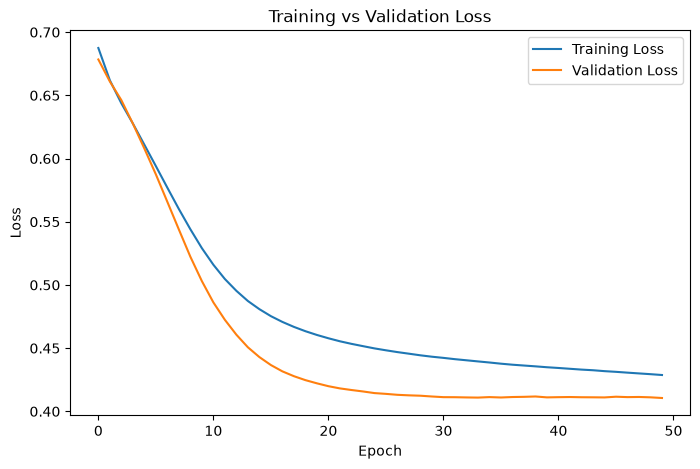

In [10]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

In [11]:
from sklearn.metrics import accuracy_score, precision_score
from sklearn.metrics import recall_score, f1_score, roc_auc_score

y_prob = model.predict(X_test)

y_pred = (y_prob > 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)
print("AUC-ROC:", auc)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Accuracy: 0.7272727272727273
Precision: 0.6304347826086957
Recall: 0.5370370370370371
F1: 0.58
AUC-ROC: 0.8399999999999999


In [12]:
log_path = "../../results/results_log.csv"

new_row = pd.DataFrame({
    "model": ["Static MLP"],
    "accuracy": [accuracy],
    "precision": [precision],
    "recall": [recall],
    "f1": [f1],
    "auc_roc": [auc]
})

try:
    results = pd.read_csv(log_path)
except FileNotFoundError:
    results = pd.DataFrame(columns=["model", "accuracy", "precision", "recall", "f1", "auc_roc"])

if "Static MLP" in results["model"].values:
    results.loc[
        results["model"] == "Static MLP",
        ["accuracy", "precision", "recall", "f1", "auc_roc"]
    ] = [accuracy, precision, recall, f1, auc]
else:
    results = pd.concat([results, new_row], ignore_index=True)

results.to_csv(log_path, index=False)

print("File Saved Successfully")

results


File Saved Successfully


,model,accuracy,precision,recall,f1,auc_roc
0,Logistic Regression,0.707792,0.604651,0.481481,0.536082,0.807037
1,RF,0.766234,0.695652,0.592593,0.640000,0.817870
2,DT,0.785700,0.698100,0.685200,0.691600,0.788700
3,SVM,0.707792,0.604651,0.481481,0.536082,0.816852
4,Static MLP,0.727273,0.630435,0.537037,0.580000,0.840000


ROC data saved successfully.


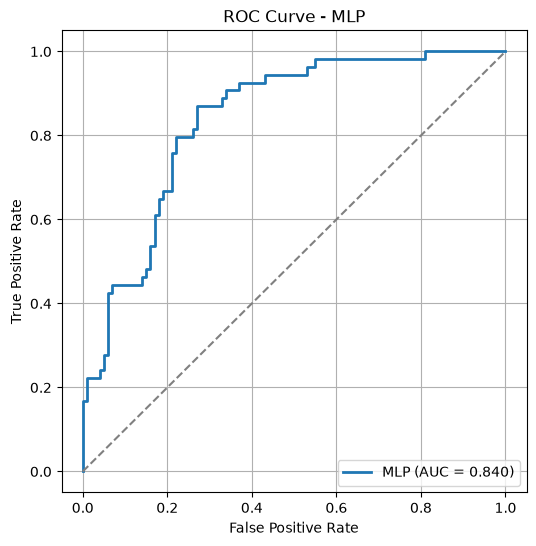

ROC curve saved successfully.


In [13]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
import os

fpr, tpr, thresholds = roc_curve(y_test, y_prob)


os.makedirs("results/roc", exist_ok=True)

roc_df = pd.DataFrame({
    "FPR": fpr,
    "TPR": tpr
})

roc_df.to_csv(
    "../../results/roc/roc_mlp.csv",
    index=False
)

print("ROC data saved successfully.")

os.makedirs("results/roc", exist_ok=True)

plt.figure(figsize=(6,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"MLP (AUC = {auc:.3f})"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="gray"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - MLP")

plt.legend(loc="lower right")
plt.grid(True)

plt.savefig(
    "../../results/roc/roc_mlp.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("ROC curve saved successfully.")

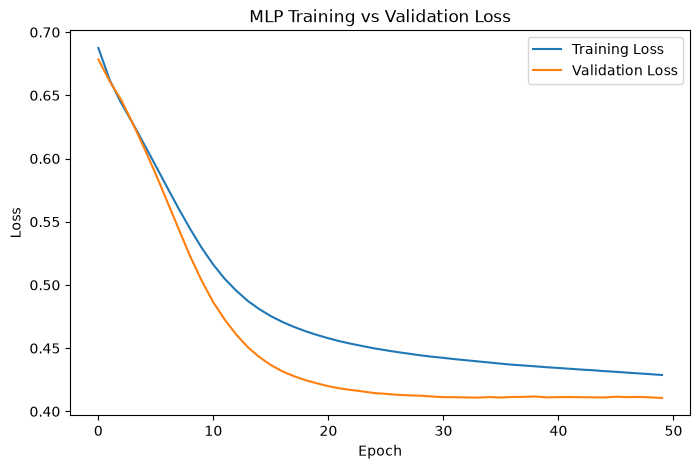

In [14]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MLP Training vs Validation Loss")
plt.legend()

plt.savefig("../../results/week4/mlp_loss_curve.png")

plt.show()

In [15]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import ReduceLROnPlateau

import numpy as np
import pandas as pd
import json

In [16]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    verbose=1,
    min_lr=1e-6
)

In [17]:
def build_model():

    model = Sequential([
        Dense(64, activation='relu',
              input_shape=(X_train.shape[1],)),

        Dropout(0.3),

        Dense(32, activation='relu'),

        Dropout(0.3),

        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [18]:
model_32 = build_model()

history_32 = model_32.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[reduce_lr],
    verbose=1
)

Epoch 1/50


/Users/mohanasritha/Desktop/Disease_detection/tf_env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4888 - loss: 0.6973 - val_accuracy: 0.6423 - val_loss: 0.6810 - learning_rate: 0.0010
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6599 - loss: 0.6686 - val_accuracy: 0.6423 - val_loss: 0.6707 - learning_rate: 0.0010
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6456 - loss: 0.6665 - val_accuracy: 0.6423 - val_loss: 0.6637 - learning_rate: 0.0010
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6558 - loss: 0.6609 - val_accuracy: 0.6423 - val_loss: 0.6561 - learning_rate: 0.0010
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6640 - loss: 0.6511 - val_accuracy: 0.6423 - val_loss: 0.6462 - learning_rate: 0.0010
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6497 - loss: 0.6544 - val_accuracy: 0.6423 - val_loss: 0.6379 - learning_rate: 0.0010
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6538 - loss: 0.6474 - val_accuracy: 0.6423 - va

In [19]:
model_64 = build_model()

history_64 = model_64.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    callbacks=[reduce_lr],
    verbose=1
)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.5784 - loss: 0.6854 - val_accuracy: 0.6667 - val_loss: 0.6752 - learning_rate: 0.0010
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6640 - loss: 0.6742 - val_accuracy: 0.6423 - val_loss: 0.6669 - learning_rate: 0.0010
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6517 - loss: 0.6670 - val_accuracy: 0.6423 - val_loss: 0.6619 - learning_rate: 0.0010
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6640 - loss: 0.6597 - val_accuracy: 0.6423 - val_loss: 0.6564 - learning_rate: 0.0010
Epoch 5/50
1/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6875 - loss: 0.6486
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6599 - loss: 0.6552 - val_accuracy: 0.6423 - val_loss: 0.6486 - learning_rate: 0.0010
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6619 - loss: 0.6423 - val_accuracy: 0.6504 - val_l

In [20]:
model_128 = build_model()

history_128 = model_128.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=128,
    validation_split=0.2,
    callbacks=[reduce_lr],
    verbose=1
)

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.5377 - loss: 0.6914 - val_accuracy: 0.6423 - val_loss: 0.6867 - learning_rate: 0.0010
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6069 - loss: 0.6840 - val_accuracy: 0.6423 - val_loss: 0.6811 - learning_rate: 0.0010
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6314 - loss: 0.6806 - val_accuracy: 0.6423 - val_loss: 0.6764 - learning_rate: 0.0010
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6497 - loss: 0.6793 - val_accuracy: 0.6423 - val_loss: 0.6726 - learning_rate: 0.0010
Epoch 5/50
1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6250 - loss: 0.6709
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6578 - loss: 0.6680 - val_accuracy: 0.6423 - val_loss: 0.6692 - learning_rate: 0.0010
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6660 - loss: 0.6639 - val_accuracy: 0.6423 - val_l

In [21]:
best_32 = max(history_32.history['val_accuracy'])

best_64 = max(history_64.history['val_accuracy'])

best_128 = max(history_128.history['val_accuracy'])

print("Batch 32 :", best_32)
print("Batch 64 :", best_64)
print("Batch 128:", best_128)

Batch 32 : 0.8130081295967102
Batch 64 : 0.6829268336296082
Batch 128: 0.642276406288147


In [22]:
results = {
    32: best_32,
    64: best_64,
    128: best_128
}

best_batch = max(results, key=results.get)

print("Best Batch Size:", best_batch)

Best Batch Size: 32


In [23]:
best_config = {
    "model": "MLP",
    "hidden_layers": [64, 32],
    "dropout": 0.3,
    "optimizer": "Adam",
    "epochs": 50,
    "batch_size": int(best_batch),
    "best_validation_accuracy": float(results[best_batch])
}

In [26]:
with open("../../results/week4/best_config.json", "w") as f:
    json.dump(best_config, f, indent=4)

print("best_config.json saved")

best_config.json saved


In [27]:
with open("../../results/week4/best_config.json") as f:
    print(f.read())

{
    "model": "MLP",
    "hidden_layers": [
        64,
        32
    ],
    "dropout": 0.3,
    "optimizer": "Adam",
    "epochs": 50,
    "batch_size": 32,
    "best_validation_accuracy": 0.8130081295967102
}


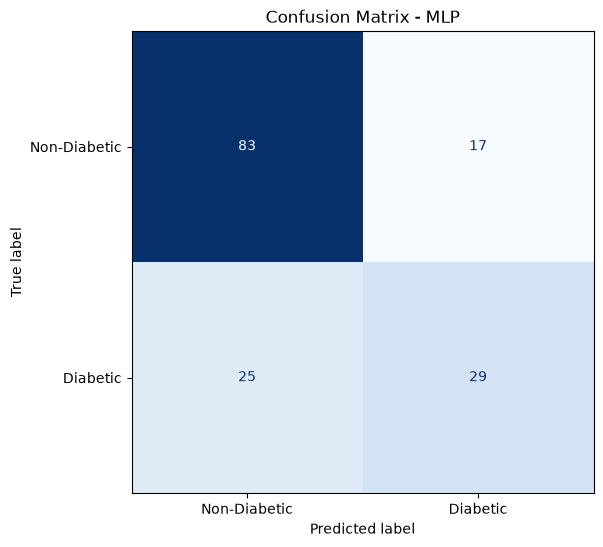

Confusion matrix saved successfully!


In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import os

cm = confusion_matrix(y_test, y_pred)

os.makedirs("../../results/matrix", exist_ok=True)

fig, ax = plt.subplots(figsize=(6,6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Diabetic", "Diabetic"]
)

disp.plot(
    cmap="Blues",
    colorbar=False,
    ax=ax
)

plt.title("Confusion Matrix - MLP")

plt.savefig(
    "../../results/matrix/confusion_matrix_mlp.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Confusion matrix saved successfully!")